# Análisis Exploratorio de Datos — Dataset UCI Colelitiasis

---

## Índice

1. [Introducción Clínica](#1-introducción-clínica)  
2. [Carga y Descripción del Dataset](#2-carga-y-descripción-del-dataset)  
   - 2.1 Estructura general  
   - 2.2 Estadísticas descriptivas  
3. [División Train / Test](#3-división-train--test)  
4. [Análisis Exploratorio Profundo (Train)](#4-análisis-exploratorio-profundo-train)  
   - 4.1 Balance de la variable objetivo  
   - 4.2 Variables categóricas y comorbilidades  
   - 4.3 Distribuciones de variables numéricas  
   - 4.4 Valores atípicos  
   - 4.5 Análisis de correlaciones  
   - 4.6 Relevancia de métricas en el contexto clínico  
5. [Preguntas de Investigación](#5-preguntas-de-investigación)

---

## 1. Introducción Clínica

La colelitiasis, comúnmente conocida como enfermedad por cálculos biliares, es una condición prevalente a nivel mundial que afecta aproximadamente al 10–15 % de la población adulta. Los cálculos biliares se forman en la vesícula biliar a partir de la precipitación de componentes de la bilis —principalmente colesterol y bilirrubina— y pueden permanecer asintomáticos durante años o progresar hacia complicaciones graves como colecistitis aguda, coledocolitiasis o pancreatitis biliar.

Diversos factores de riesgo metabólicos han sido asociados con su desarrollo, entre los que destacan la obesidad, la dislipidemia, la diabetes mellitus, el sedentarismo y el género femenino. El diagnóstico definitivo se realiza mediante ecografía abdominal, pero la identificación temprana de pacientes en riesgo mediante variables clínicas y bioquímicas representa una oportunidad para la prevención y el manejo oportuno.

El presente análisis utiliza el dataset UCI de colelitiasis, un conjunto de datos clínicos que incluye variables antropométricas, de composición corporal obtenidas por bioimpedancia, marcadores bioquímicos en sangre y comorbilidades asociadas. El objetivo es construir y evaluar modelos de clasificación capaces de predecir la presencia de cálculos biliares a partir de dicha información, identificando los factores de mayor relevancia predictiva en este contexto clínico.

> **Nota sobre la codificación de la variable objetivo:** `Gallstone Status = 0` indica ausencia de cálculos biliares (paciente sano), mientras que `Gallstone Status = 1` indica presencia de cálculos (paciente enfermo).

---

## 2. Carga y Descripción del Dataset

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Rutas
DATA_PATH = Path("../data/raw/dataset-uci.csv")
DOCS_PATH = Path("../docs")
PROCESSED_PATH = Path("../data/processed")
DOCS_PATH.mkdir(parents=True, exist_ok=True)
PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

# Estilo global
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(DATA_PATH)
print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")

Dimensiones: 319 filas × 39 columnas


### 2.1 Estructura General

In [66]:
print("=== Primeras filas ===")
df.head()

=== Primeras filas ===


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


In [67]:
print("=== Tipos de datos ===")
print(df.dtypes.to_string())

=== Tipos de datos ===
Gallstone Status                                    int64
Age                                                 int64
Gender                                              int64
Comorbidity                                         int64
Coronary Artery Disease (CAD)                       int64
Hypothyroidism                                      int64
Hyperlipidemia                                      int64
Diabetes Mellitus (DM)                              int64
Height                                              int64
Weight                                            float64
Body Mass Index (BMI)                             float64
Total Body Water (TBW)                            float64
Extracellular Water (ECW)                         float64
Intracellular Water (ICW)                         float64
Extracellular Fluid/Total Body Water (ECF/TBW)    float64
Total Body Fat Ratio (TBFR) (%)                   float64
Lean Mass (LM) (%)                               

In [68]:
print("=== Valores faltantes ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.any() else "No se detectaron valores faltantes.")

=== Valores faltantes ===
No se detectaron valores faltantes.


### 2.2 Estadísticas Descriptivas

In [69]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.50,0.50,0.00,0.00,0.00,1.00,1.00
Age,319.0,48.07,12.11,20.00,38.50,49.00,56.00,96.00
Gender,319.0,0.49,0.50,0.00,0.00,0.00,1.00,1.00
Comorbidity,319.0,0.34,0.52,0.00,0.00,0.00,1.00,3.00
Coronary Artery Disease (CAD),319.0,0.04,0.19,0.00,0.00,0.00,0.00,1.00
Hypothyroidism,319.0,0.03,0.17,0.00,0.00,0.00,0.00,1.00
Hyperlipidemia,319.0,0.03,0.16,0.00,0.00,0.00,0.00,1.00
Diabetes Mellitus (DM),319.0,0.13,0.34,0.00,0.00,0.00,0.00,1.00
Height,319.0,167.16,10.05,145.00,159.50,168.00,175.00,191.00
Weight,319.0,80.56,15.71,42.90,69.60,78.80,91.25,143.50


---

## 3. División Train / Test

Se aplica una división estratificada 80/20 con `random_state=123`, de modo que la proporción de cada clase en el target se preserva en ambas particiones. **Todo el análisis posterior se realiza exclusivamente sobre el conjunto de entrenamiento**, para evitar que la información del test influya en las decisiones de preprocesamiento y modelado.

In [70]:
from sklearn.model_selection import train_test_split

TARGET = "Gallstone Status"
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

# Persistir particiones crudas
X_train.to_csv(PROCESSED_PATH / "X_train_raw.csv", index=False)
X_test.to_csv(PROCESSED_PATH / "X_test_raw.csv", index=False)
y_train.to_csv(PROCESSED_PATH / "y_train.csv", index=False)
y_test.to_csv(PROCESSED_PATH / "y_test.csv", index=False)

print(f"Train: {X_train.shape[0]} registros | Test: {X_test.shape[0]} registros")
print(f"Distribución train — clase 0: {(y_train==0).sum()} | clase 1: {(y_train==1).sum()}")
print(f"Distribución test  — clase 0: {(y_test==0).sum()}  | clase 1: {(y_test==1).sum()}")

Train: 255 registros | Test: 64 registros
Distribución train — clase 0: 129 | clase 1: 126
Distribución test  — clase 0: 32  | clase 1: 32


---

## 4. Análisis Exploratorio Profundo (Train)

> A partir de este punto, todo análisis se restringe al conjunto de entrenamiento (`X_train`, `y_train`). Esto garantiza que las decisiones tomadas durante la exploración —selección de variables, detección de outliers, estrategias de imputación— no estén contaminadas por información del conjunto de prueba.

In [71]:
train = X_train.copy()
train[TARGET] = y_train.values

### 4.1 Balance de la Variable Objetivo

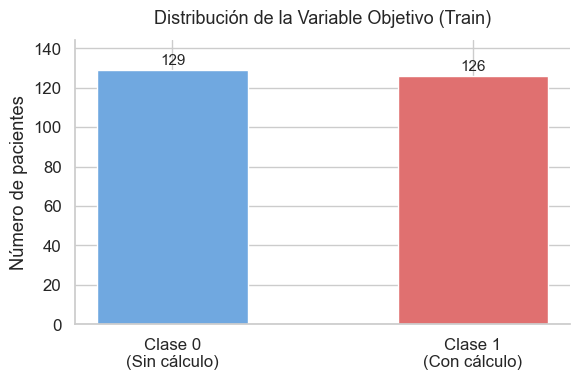

In [72]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = train[TARGET].value_counts().sort_index()
bars = ax.bar(
    ["Clase 0\n(Sin cálculo)", "Clase 1\n(Con cálculo)"],
    counts.values,
    color=["#70A8E0", "#E07070"],
    edgecolor="white",
    width=0.5
)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(val), ha="center", va="bottom", fontsize=11)
ax.set_title("Distribución de la Variable Objetivo (Train)", fontsize=13, pad=12)
ax.set_ylabel("Número de pacientes")
ax.set_ylim(0, counts.max() + 15)
sns.despine()
plt.tight_layout()
plt.savefig(DOCS_PATH / "01_balance_clases.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 Variables Categóricas y Comorbilidades

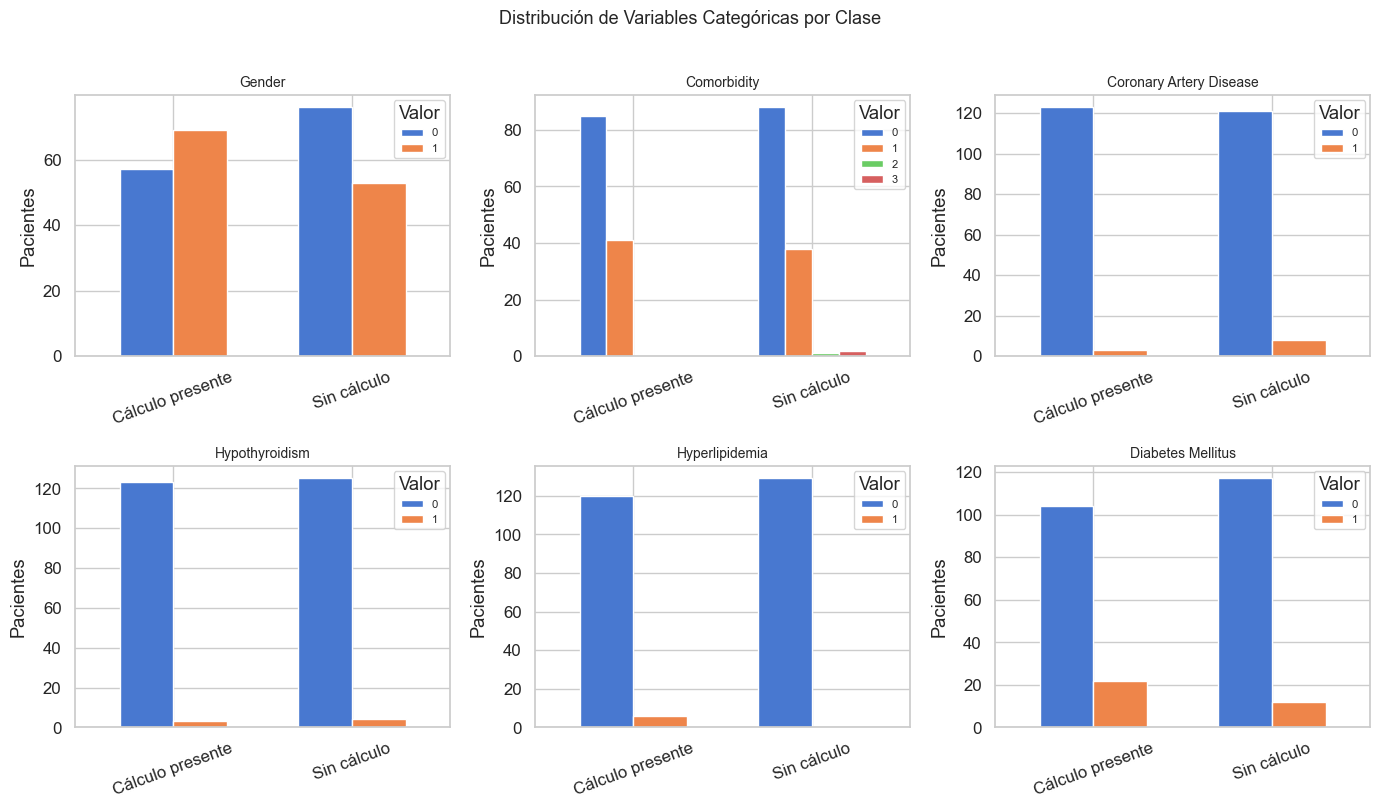

In [73]:
# Frecuencia de comorbilidades por clase
comorbilidades = [
    "Gender", "Comorbidity",
    "Coronary Artery Disease (CAD)", "Hypothyroidism",
    "Hyperlipidemia", "Diabetes Mellitus (DM)"
]

label_map = {0: "Sin cálculo", 1: "Cálculo presente"}
train["Clase"] = train[TARGET].map(label_map)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(comorbilidades):
    prop = (
        train.groupby(["Clase", col])
        .size()
        .unstack(fill_value=0)
    )
    prop.plot(kind="bar", ax=axes[i], edgecolor="white", width=0.6)
    short = col.split(" (")[0]
    axes[i].set_title(short, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Pacientes")
    axes[i].tick_params(axis="x", rotation=20)
    axes[i].legend(title="Valor", fontsize=8)

fig.suptitle("Distribución de Variables Categóricas por Clase", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_PATH / "02_categoricas_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Distribuciones de Variables Numéricas Clave

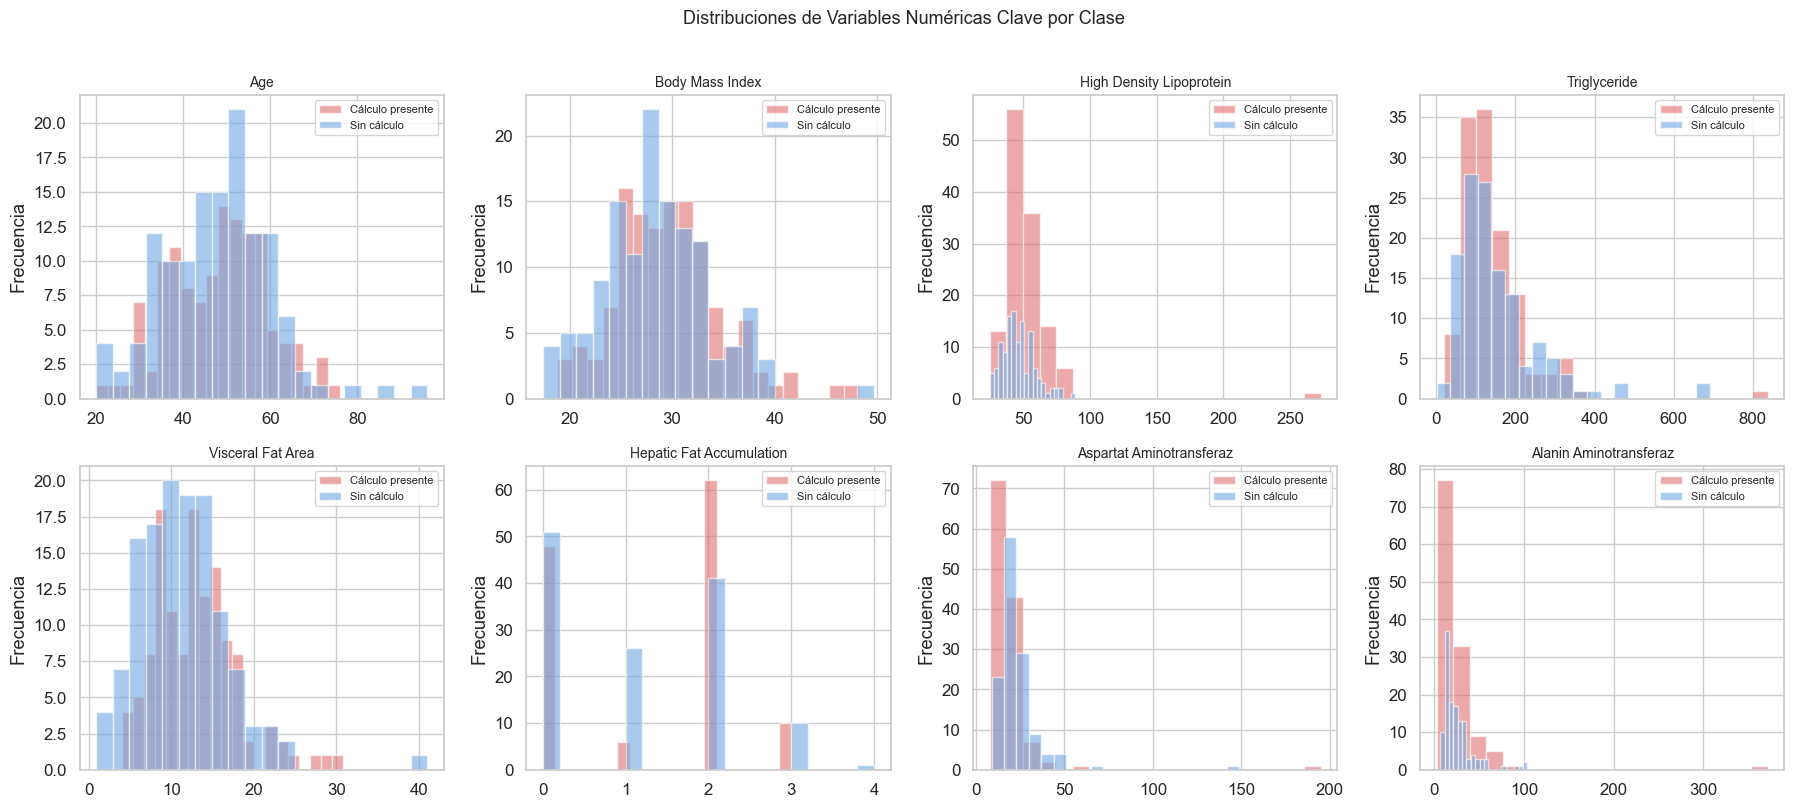

In [74]:
num_vars = [
    "Age", "Body Mass Index (BMI)",
    "High Density Lipoprotein (HDL)", "Triglyceride",
    "Visceral Fat Area (VFA)", "Hepatic Fat Accumulation (HFA)",
    "Aspartat Aminotransferaz (AST)", "Alanin Aminotransferaz (ALT)"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = {"Cálculo presente": "#E07070", "Sin cálculo": "#70A8E0"}

for i, col in enumerate(num_vars):
    for clase, grp in train.groupby("Clase"):
        axes[i].hist(
            grp[col].dropna(), bins=20, alpha=0.6,
            label=clase, color=colors[clase], edgecolor="white"
        )
    short = col.split(" (")[0]
    axes[i].set_title(short, fontsize=10)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribuciones de Variables Numéricas Clave por Clase", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_PATH / "03_distribuciones_numericas.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.4 Valores Atípicos

In [75]:
# Detectar outliers usando IQR
numeric_cols = train.select_dtypes(include=[np.number]).drop(columns=[TARGET]).columns

outlier_summary = []
for col in numeric_cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((train[col] < lower) | (train[col] > upper)).sum()
    if n_out > 0:
        outlier_summary.append({"Variable": col, "N outliers": n_out,
                                  "Mín": train[col].min(), "Máx": train[col].max()})

out_df = pd.DataFrame(outlier_summary).sort_values("N outliers", ascending=False)
print(f"Variables con outliers detectados: {len(out_df)}")
out_df

Variables con outliers detectados: 30


,Variable,N outliers,Mín,Máx
5,Diabetes Mellitus (DM),34,0.00,1.00
27,C-Reactive Protein (CRP),26,0.00,43.40
17,Glucose,19,69.00,575.00
23,Alanin Aminotransferaz (ALT),19,3.00,372.00
22,Aspartat Aminotransferaz (AST),15,8.00,195.00
21,Triglyceride,14,1.39,838.00
26,Glomerular Filtration Rate (GFR),11,10.60,132.00
2,Coronary Artery Disease (CAD),11,0.00,1.00
24,Alkaline Phosphatase (ALP),10,7.00,197.00
11,Body Protein Content (Protein) (%),8,5.56,24.81


C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\2583560648.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\2583560648.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\2583560648.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(
C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\2583560648.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be d

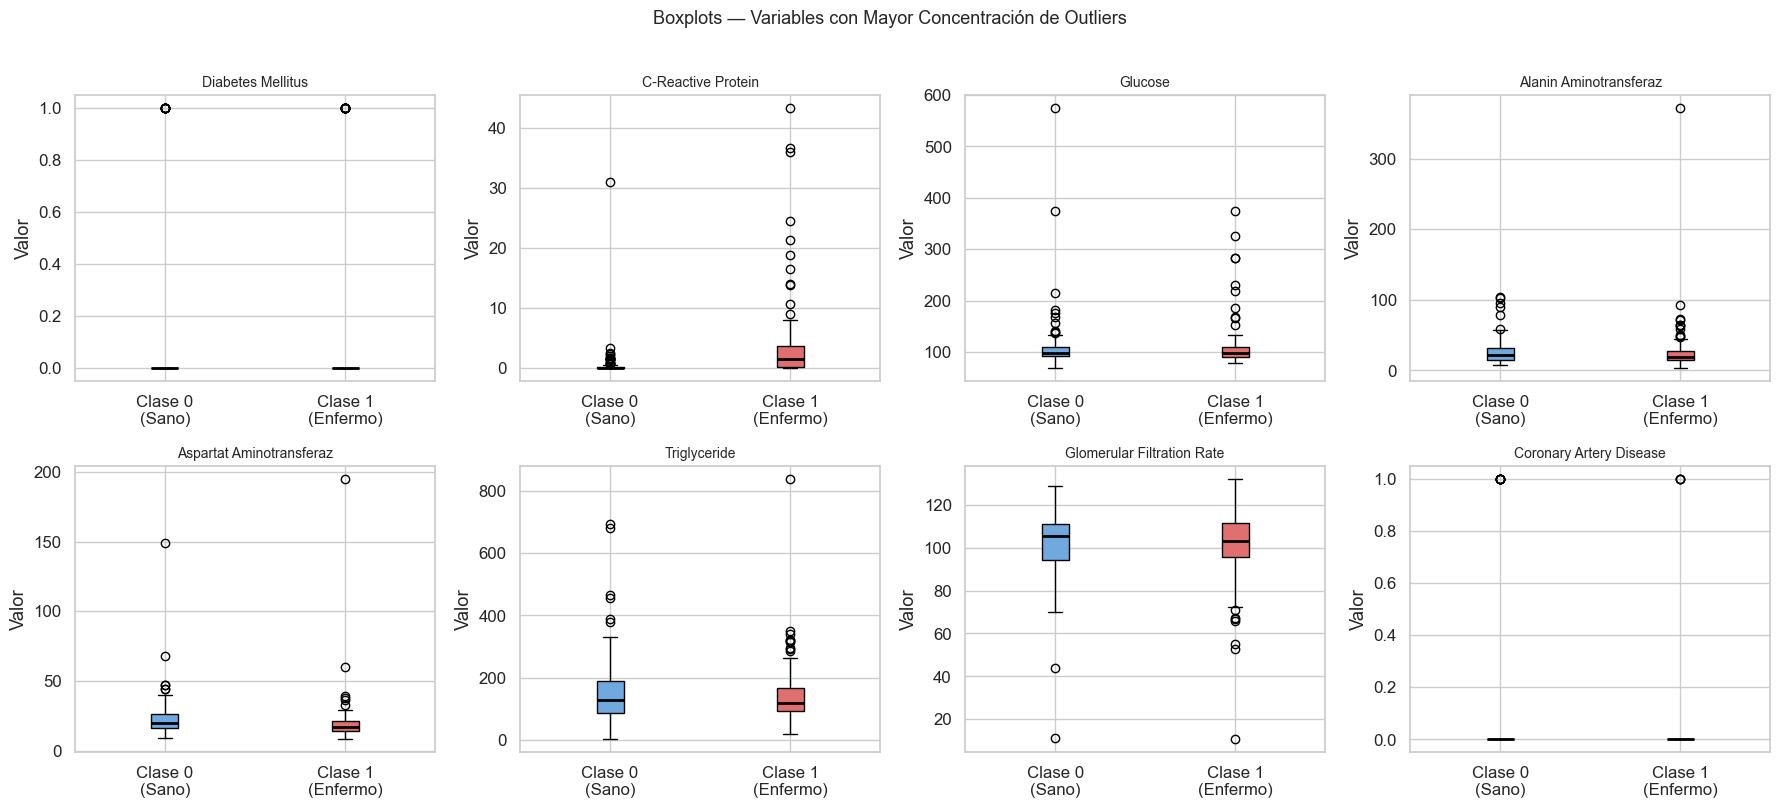

In [76]:
# Boxplots para las variables con más outliers
top_outlier_vars = out_df.head(8)["Variable"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(top_outlier_vars):
    data_by_class = [train.loc[train[TARGET] == cls, col].dropna() for cls in [0, 1]]
    bp = axes[i].boxplot(
        data_by_class,
        labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2)
    )
    bp["boxes"][0].set_facecolor("#70A8E0")
    bp["boxes"][1].set_facecolor("#E07070")
    short = col.split(" (")[0]
    axes[i].set_title(short, fontsize=10)
    axes[i].set_ylabel("Valor")

fig.suptitle("Boxplots — Variables con Mayor Concentración de Outliers", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(DOCS_PATH / "04_boxplots_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

In [77]:
# Inspección especial: Obesity (%)
obesity_col = "Obesity (%)"
print("Estadísticas de Obesity (%):")
print(train[obesity_col].describe())
print(f"\nValores extremos (>200): {(train[obesity_col] > 200).sum()} registro(s)")
print(train.loc[train[obesity_col] > 200, [obesity_col, TARGET]])

Estadísticas de Obesity (%):
count     255.000000
mean       38.297686
std       122.325623
min         0.400000
25%        14.100000
50%        27.670000
75%        43.035000
max      1954.000000
Name: Obesity (%), dtype: float64

Valores extremos (>200): 1 registro(s)
     Obesity (%)  Gallstone Status
239       1954.0                 1


### 4.5 Análisis de Correlaciones

Se analiza la correlación entre variables numéricas para identificar redundancias (multicolinealidad). Las variables altamente correlacionadas entre sí aportan información redundante al modelo y serán candidatas a eliminación en el preprocesamiento.

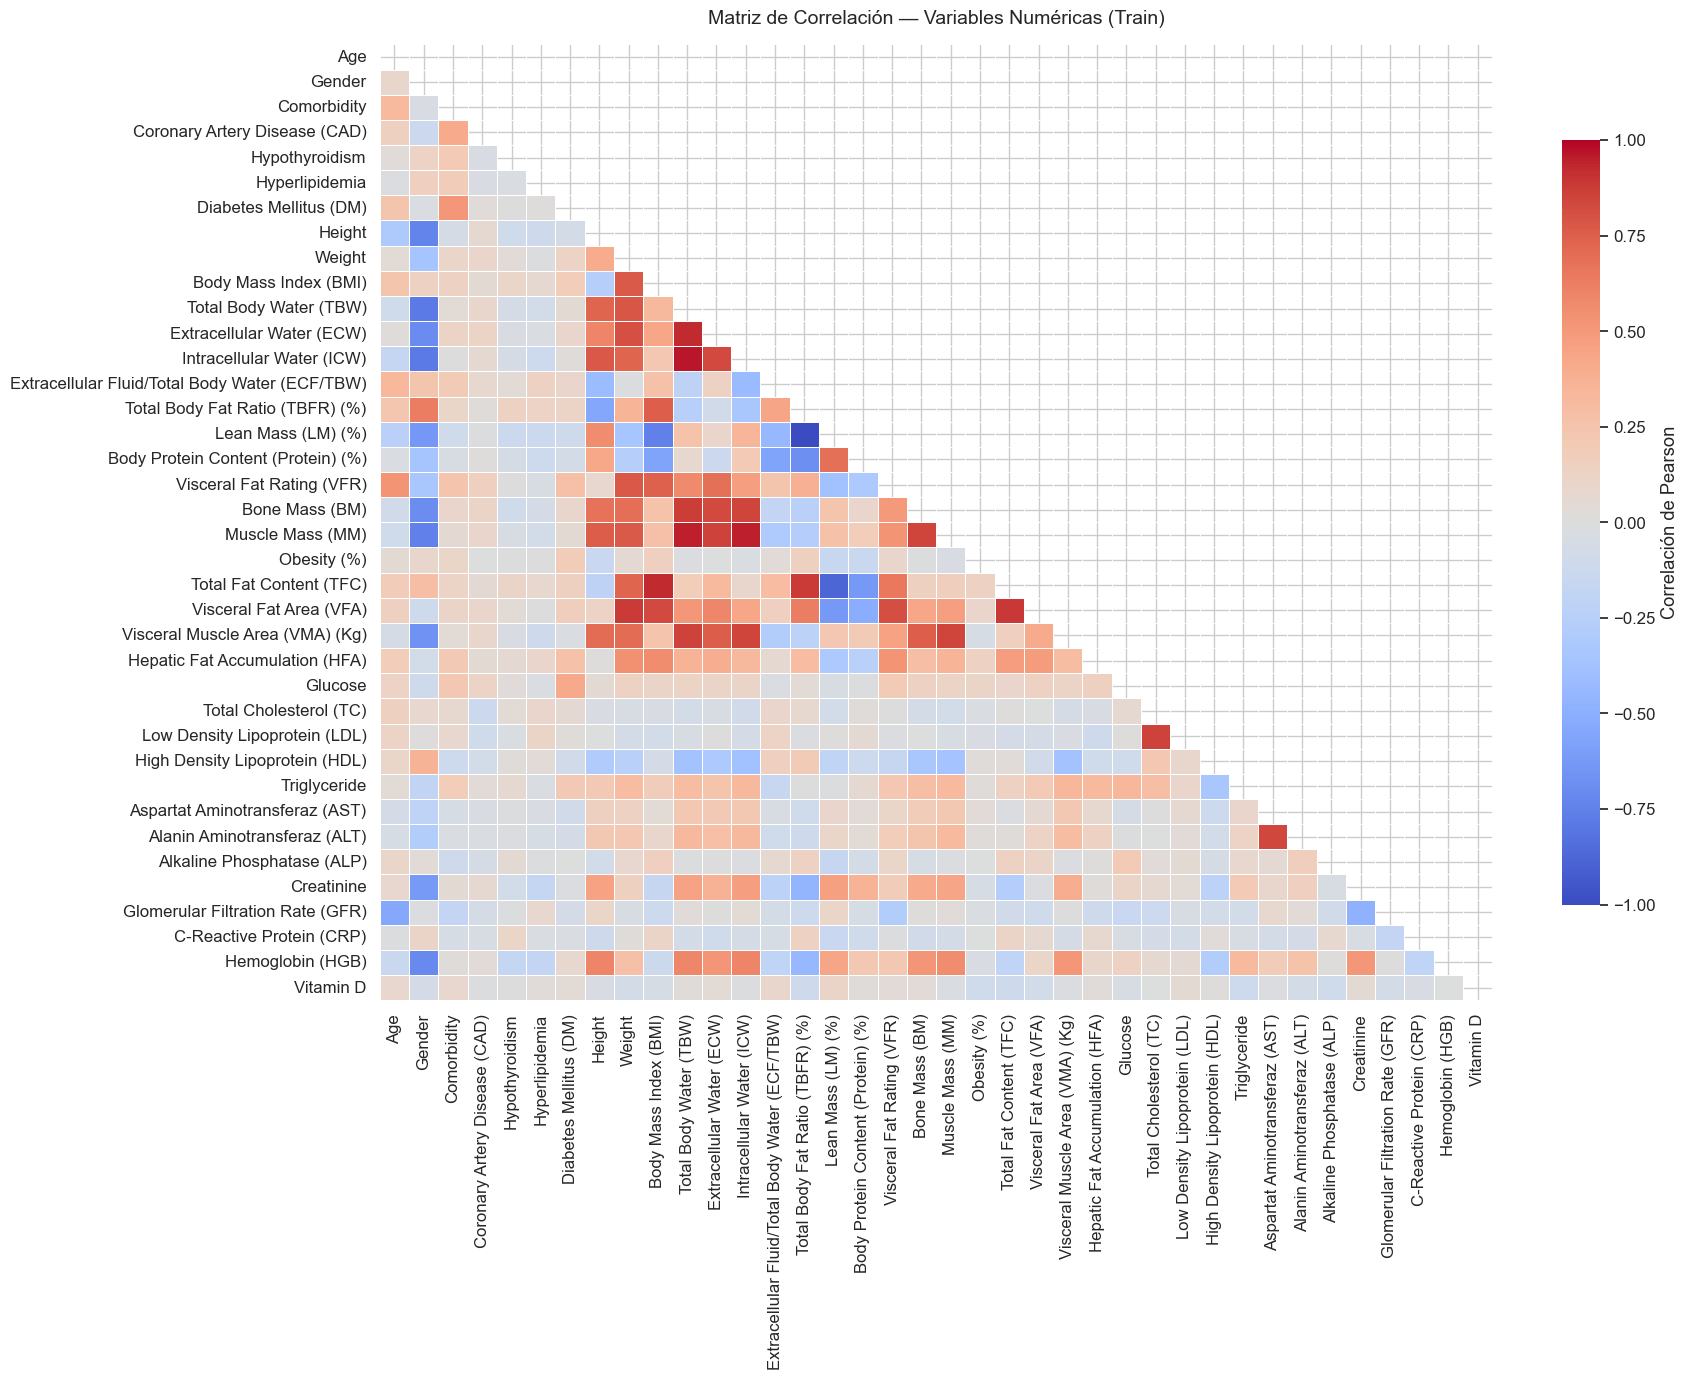

In [78]:
corr = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 14))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=False, cmap="coolwarm", center=0,
    vmin=-1, vmax=1, ax=ax, linewidths=0.4,
    cbar_kws={"shrink": 0.8, "label": "Correlación de Pearson"}
)
ax.set_title("Matriz de Correlación — Variables Numéricas (Train)", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(DOCS_PATH / "05_heatmap_correlaciones.png", dpi=150, bbox_inches="tight")
plt.show()

In [79]:
# Pares con correlación absoluta > 0.85
high_corr = (
    corr.abs()
    .where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
high_corr.columns = ["Variable A", "Variable B", "|Correlación|"]
high_corr = high_corr[high_corr["|Correlación|"] > 0.85].sort_values("|Correlación|", ascending=False)
print(f"Pares con |correlación| > 0.85: {len(high_corr)}")
high_corr.round(3)

Pares con |correlación| > 0.85: 14


,Variable A,Variable B,|Correlación|
547,Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),0.992
392,Total Body Water (TBW),Intracellular Water (ICW),0.966
475,Intracellular Water (ICW),Muscle Mass (MM),0.951
399,Total Body Water (TBW),Muscle Mass (MM),0.948
391,Total Body Water (TBW),Extracellular Water (ECW),0.929
363,Body Mass Index (BMI),Total Fat Content (TFC),0.922
820,Total Fat Content (TFC),Visceral Fat Area (VFA),0.883
326,Weight,Visceral Fat Area (VFA),0.881
553,Total Body Fat Ratio (TBFR) (%),Total Fat Content (TFC),0.879
591,Lean Mass (LM) (%),Total Fat Content (TFC),0.878


### 4.6 Relevancia de Métricas en el Contexto Clínico

En un problema de clasificación médica, no todas las métricas tienen el mismo peso. La elección de la métrica principal debe responder a las consecuencias clínicas de cada tipo de error:

| Situación | Descripción | Consecuencia clínica |
|---|---|---|
| **Verdadero Positivo (VP)** | Paciente enfermo predicho como enfermo | Derivación y tratamiento oportuno |
| **Falso Negativo (FN)** | Paciente enfermo predicho como sano | **Riesgo grave: colecistitis, pancreatitis biliar, sepsis** |
| **Falso Positivo (FP)** | Paciente sano predicho como enfermo | Estudios adicionales innecesarios (ecografía), costo e incomodidad |
| **Verdadero Negativo (VN)** | Paciente sano predicho como sano | Alta sin intervención innecesaria |

**Métrica primaria: Recall (Sensibilidad) sobre la clase 1 (enfermo)**  
Un falso negativo implica no detectar un cálculo biliar presente, lo cual puede desencadenar complicaciones potencialmente graves e incluso fatales. Por este motivo, maximizar el recall de la clase enferma es la prioridad clínica sobre la precisión.

**Métricas de soporte:**  
- **Precision (clase 1):** relevante para controlar la tasa de falsos positivos y evitar intervenciones innecesarias.  
- **F1-score:** balance entre recall y precision, útil para evaluar el rendimiento general.  
- **ROC-AUC:** mide la capacidad discriminativa general del modelo independientemente del umbral.  
- **Accuracy:** menos relevante en contextos clínicos si las consecuencias de los errores no son simétricas.

---

## 5. Preguntas de Investigación

A continuación se plantean seis preguntas orientadas a entender la relación entre las variables clínicas y la presencia de cálculos biliares. Cada pregunta se acompaña de visualización y análisis interpretativo.

---

### Pregunta 1: ¿Cómo difiere el índice de masa corporal (IMC) entre pacientes con y sin cálculos biliares?

C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\3189071071.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_bmi, labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],


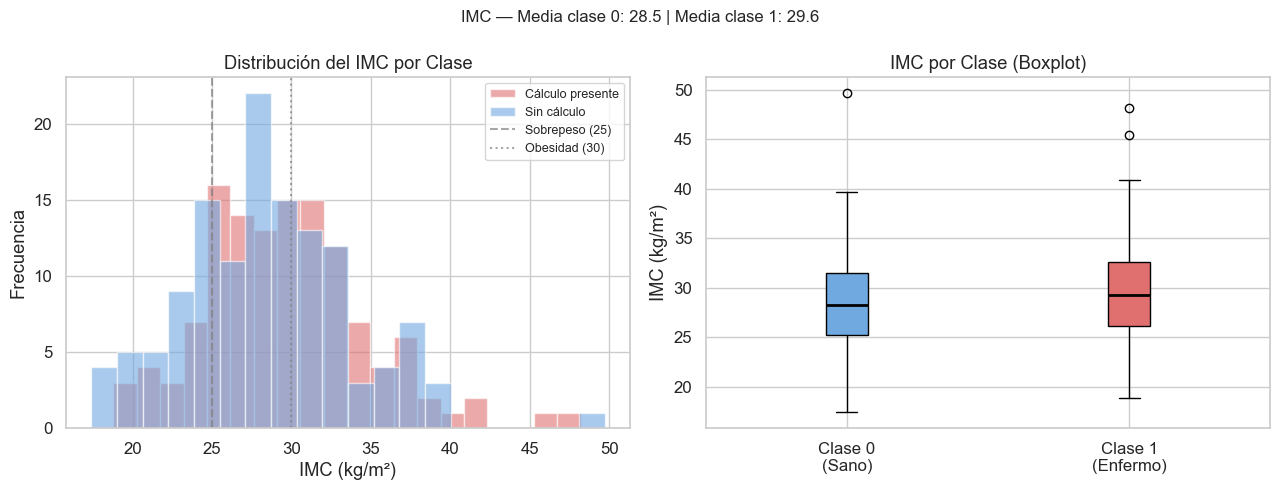


Mediana IMC — Clase 0 (sano):    28.2
Mediana IMC — Clase 1 (enfermo): 29.2


In [80]:
bmi_col = "Body Mass Index (BMI)"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma superpuesto
for clase, grp in train.groupby("Clase"):
    axes[0].hist(grp[bmi_col].dropna(), bins=20, alpha=0.6,
                 label=clase, color=colors[clase], edgecolor="white")
axes[0].set_title("Distribución del IMC por Clase")
axes[0].set_xlabel("IMC (kg/m²)")
axes[0].set_ylabel("Frecuencia")
axes[0].axvline(25, color="gray", linestyle="--", alpha=0.7, label="Sobrepeso (25)")
axes[0].axvline(30, color="gray", linestyle=":",  alpha=0.7, label="Obesidad (30)")
axes[0].legend(fontsize=9)

# Boxplot
data_bmi = [train.loc[train[TARGET] == cls, bmi_col].dropna() for cls in [0, 1]]
bp = axes[1].boxplot(data_bmi, labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],
                     patch_artist=True, medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#70A8E0")
bp["boxes"][1].set_facecolor("#E07070")
axes[1].set_title("IMC por Clase (Boxplot)")
axes[1].set_ylabel("IMC (kg/m²)")

# Estadísticas en el título
m0 = train.loc[train[TARGET] == 0, bmi_col].mean()
m1 = train.loc[train[TARGET] == 1, bmi_col].mean()
fig.suptitle(f"IMC — Media clase 0: {m0:.1f} | Media clase 1: {m1:.1f}", fontsize=12)

plt.tight_layout()
plt.savefig(DOCS_PATH / "P1_imc_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMediana IMC — Clase 0 (sano):    {train.loc[train[TARGET]==0, bmi_col].median():.1f}")
print(f"Mediana IMC — Clase 1 (enfermo): {train.loc[train[TARGET]==1, bmi_col].median():.1f}")

**Interpretación:** Los pacientes con cálculos biliares tienden a presentar valores de IMC más elevados, consistente con la conocida asociación entre obesidad y colelitiasis. Un IMC superior a 30 kg/m² se considera factor de riesgo independiente para la formación de cálculos de colesterol.

---

### Pregunta 2: ¿El género es un factor diferenciador en la presencia de cálculos biliares?

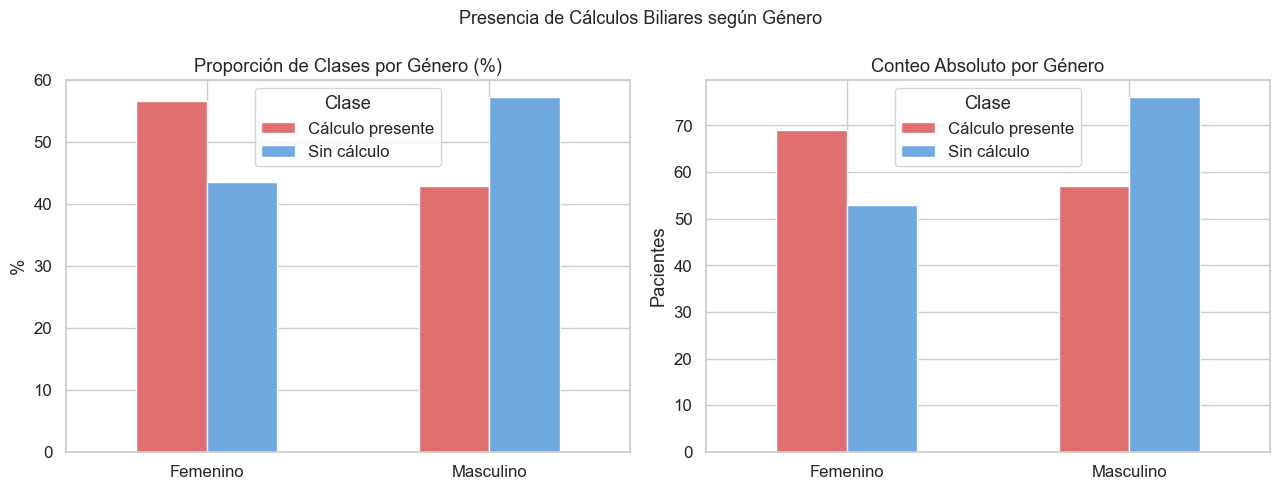

In [81]:
gender_map = {0: "Masculino", 1: "Femenino"}
train["Género"] = train["Gender"].map(gender_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Proporción de enfermos (clase 1) por género
prop_gender = (
    train.groupby(["Género", "Clase"])
    .size()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)
)
prop_gender.plot(kind="bar", ax=axes[0],
                 color=["#E07070", "#70A8E0"], edgecolor="white", width=0.5)
axes[0].set_title("Proporción de Clases por Género (%)")
axes[0].set_xlabel("")
axes[0].set_ylabel("%")
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="Clase")

# Conteo absoluto
abs_gender = (
    train.groupby(["Género", "Clase"])
    .size()
    .unstack(fill_value=0)
)
abs_gender.plot(kind="bar", ax=axes[1],
                color=["#E07070", "#70A8E0"], edgecolor="white", width=0.5)
axes[1].set_title("Conteo Absoluto por Género")
axes[1].set_xlabel("")
axes[1].set_ylabel("Pacientes")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="Clase")

fig.suptitle("Presencia de Cálculos Biliares según Género", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "P2_genero_vs_clase.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** La literatura médica establece que las mujeres tienen una prevalencia de colelitiasis aproximadamente 2–3 veces mayor que los hombres, atribuida a factores hormonales (estrógeno y progesterona favorecen la supersaturación de colesterol en bilis). Los datos del conjunto de entrenamiento permiten verificar si esta tendencia se replica en la muestra.

---

### Pregunta 3: ¿El perfil lipídico (HDL bajo, Triglicéridos altos) distingue a los grupos?

C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\4031344875.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],
C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\4031344875.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],
C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\4031344875.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot(data, labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],
C:\Users\Gizmo\AppData\Local\Temp\ipykernel_13024\40

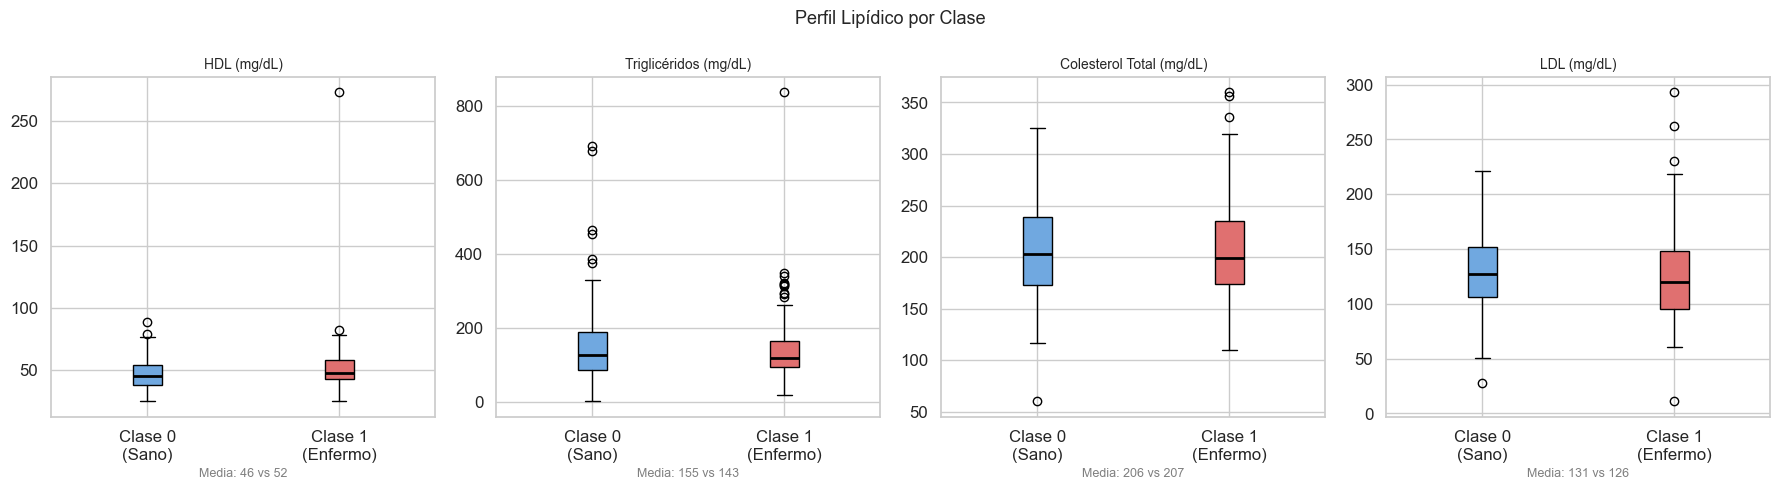

In [82]:
lipid_vars = [
    ("High Density Lipoprotein (HDL)", "HDL (mg/dL)"),
    ("Triglyceride", "Triglicéridos (mg/dL)"),
    ("Total Cholesterol (TC)", "Colesterol Total (mg/dL)"),
    ("Low Density Lipoprotein (LDL)", "LDL (mg/dL)")
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (col, label) in enumerate(lipid_vars):
    data = [train.loc[train[TARGET] == cls, col].dropna() for cls in [0, 1]]
    bp = axes[i].boxplot(data, labels=["Clase 0\n(Sano)", "Clase 1\n(Enfermo)"],
                         patch_artist=True, medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#70A8E0")
    bp["boxes"][1].set_facecolor("#E07070")
    axes[i].set_title(label, fontsize=10)
    m0 = train.loc[train[TARGET] == 0, col].mean()
    m1 = train.loc[train[TARGET] == 1, col].mean()
    axes[i].set_xlabel(f"Media: {m0:.0f} vs {m1:.0f}", fontsize=9, color="gray")

fig.suptitle("Perfil Lipídico por Clase", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "P3_perfil_lipidico.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** El HDL bajo y los triglicéridos elevados son marcadores del síndrome metabólico, condición frecuentemente asociada a colelitiasis. Un HDL reducido implica menor capacidad de transporte inverso del colesterol, favoreciendo su acumulación en la bilis. Los triglicéridos elevados reflejan disfunción lipídica que también altera la composición biliar.

---

### Pregunta 4: ¿La acumulación de grasa visceral y hepática (VFA, HFA) es mayor en pacientes con cálculos?

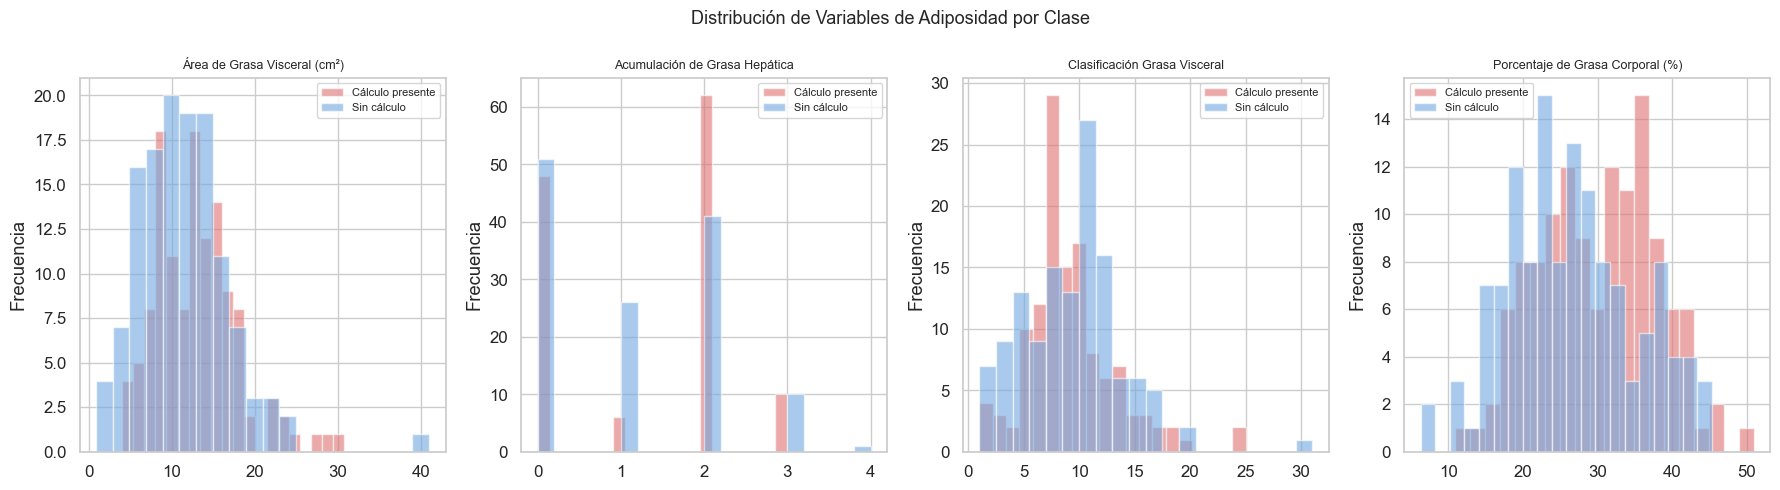

Visceral Fat Area (VFA)                       | Clase 0:  11.52 | Clase 1:  12.98
Hepatic Fat Accumulation (HFA)                | Clase 0:   1.10 | Clase 1:   1.27
Visceral Fat Rating (VFR)                     | Clase 0:   9.10 | Clase 1:   9.20
Total Body Fat Ratio (TBFR) (%)               | Clase 0:  26.44 | Clase 1:  30.16


In [83]:
fat_vars = [
    ("Visceral Fat Area (VFA)", "Área de Grasa Visceral (cm²)"),
    ("Hepatic Fat Accumulation (HFA)", "Acumulación de Grasa Hepática"),
    ("Visceral Fat Rating (VFR)", "Clasificación Grasa Visceral"),
    ("Total Body Fat Ratio (TBFR) (%)", "Porcentaje de Grasa Corporal (%)")
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (col, label) in enumerate(fat_vars):
    for clase, grp in train.groupby("Clase"):
        axes[i].hist(grp[col].dropna(), bins=20, alpha=0.6,
                     label=clase, color=colors[clase], edgecolor="white")
    axes[i].set_title(label, fontsize=9)
    axes[i].set_ylabel("Frecuencia")
    axes[i].legend(fontsize=8)

fig.suptitle("Distribución de Variables de Adiposidad por Clase", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "P4_grasa_visceral_hepatica.png", dpi=150, bbox_inches="tight")
plt.show()

for col, _ in fat_vars:
    m0 = train.loc[train[TARGET]==0, col].mean()
    m1 = train.loc[train[TARGET]==1, col].mean()
    print(f"{col:45s} | Clase 0: {m0:6.2f} | Clase 1: {m1:6.2f}")

**Interpretación:** La grasa visceral y la grasa hepática (hígado graso) están estrechamente vinculadas con la colelitiasis a través de mecanismos metabólicos comunes. El hígado graso altera la composición de la bilis aumentando la secreción de colesterol, mientras que la grasa visceral elevada promueve resistencia a la insulina y dislipidemia, ambos factores litogénicos.

---

### Pregunta 5: ¿Los pacientes con comorbilidades metabólicas (DM, Hiperlipidemia) presentan mayor prevalencia de cálculos?

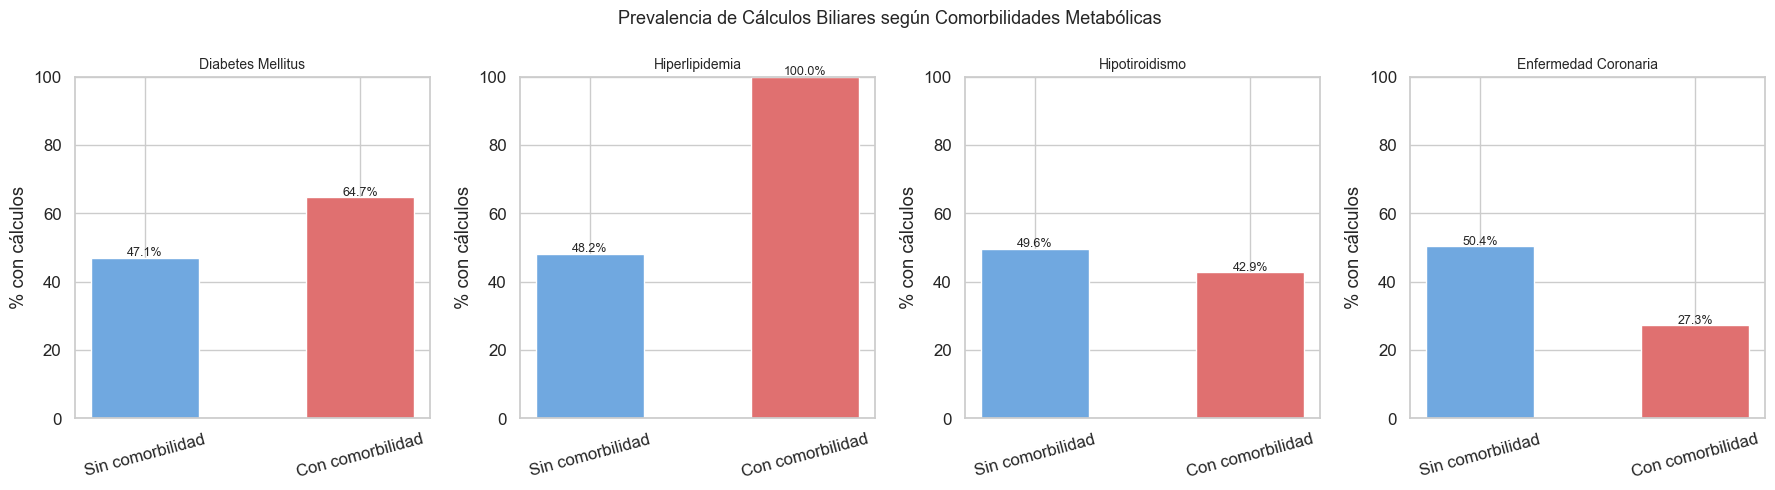

In [86]:
comorbilidades_metabolicas = [
    ("Diabetes Mellitus (DM)", "Diabetes Mellitus"),
    ("Hyperlipidemia", "Hiperlipidemia"),
    ("Hypothyroidism", "Hipotiroidismo"),
    ("Coronary Artery Disease (CAD)", "Enfermedad Coronaria")
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for i, (col, label) in enumerate(comorbilidades_metabolicas):
    prev = (
        train.groupby(col)[TARGET]
        .apply(lambda x: (x == 1).mean() * 100)
        .reset_index()
    )
    prev.columns = [col, "Prevalencia Cálculos (%)"]
    prev[col] = prev[col].map({0: "Sin comorbilidad", 1: "Con comorbilidad"})
    axes[i].bar(prev[col], prev["Prevalencia Cálculos (%)"],
                color=["#70A8E0", "#E07070"], edgecolor="white", width=0.5)
    for _, row in prev.iterrows():
        axes[i].text(row[col], row["Prevalencia Cálculos (%)"] + 0.5,
                     f"{row['Prevalencia Cálculos (%)']:.1f}%",
                     ha="center", fontsize=9)
    axes[i].set_title(label, fontsize=10)
    axes[i].set_ylabel("% con cálculos")
    axes[i].set_ylim(0, 100)
    axes[i].tick_params(axis="x", rotation=15)

fig.suptitle("Prevalencia de Cálculos Biliares según Comorbilidades Metabólicas", fontsize=13)
plt.tight_layout()
plt.savefig(DOCS_PATH / "P5_comorbilidades_metabolicas.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretación:** La diabetes mellitus y la hiperlipidemia son componentes del síndrome metabólico, asociado a mayor riesgo de colelitiasis por mecanismos compartidos: hiperinsulinemia que aumenta la secreción biliar de colesterol, y dislipidemias que alteran el equilibrio de los ácidos biliares. Una mayor prevalencia de cálculos en pacientes con estas comorbilidades respaldaría su valor como variables predictoras en el modelo.